# Iris Flower Classification

## 1. Import Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load the Dataset

In [3]:
file_path = "IRIS.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


## 3. Understand the Dataset

In [4]:
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()


First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Dataset shape: (150, 5)

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## 4. Identify Target Column

In [6]:
target_column = None

for column in df.columns:
    if "species" in column.lower():
        target_column = column
        break

if target_column is None:
    target_column = df.columns[-1]

print("\nTarget column:", target_column)


Target column: species


## 5. Data Cleaning

In [7]:
id_columns = [column for column in df.columns if "id" == column.lower()]

if id_columns:
    df = df.drop(columns=id_columns)

## 6. Exploratory Data Analysis

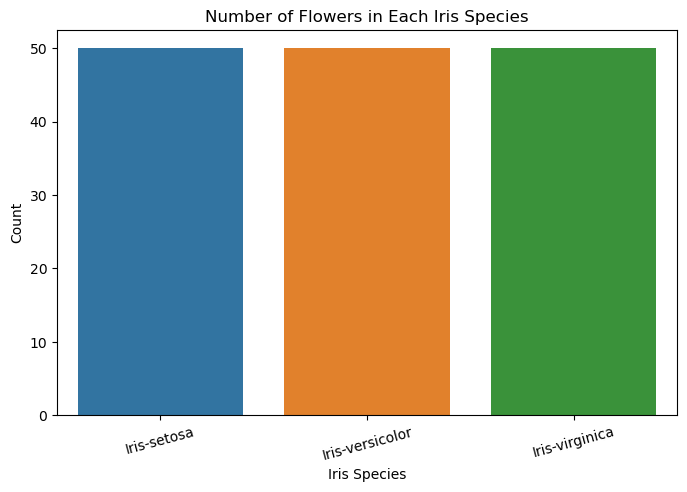

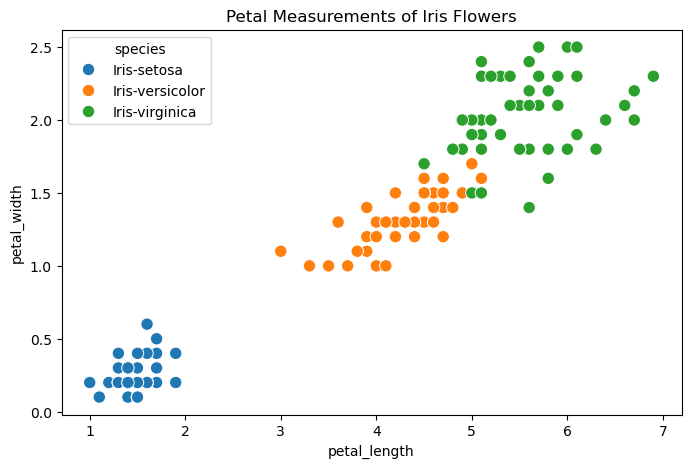

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_column, hue=target_column, legend=False)
plt.title("Number of Flowers in Each Iris Species")
plt.xlabel("Iris Species")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

feature_columns = [column for column in df.columns if column != target_column]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x=feature_columns[2],
    y=feature_columns[3],
    hue=target_column,
    s=80
)
plt.title("Petal Measurements of Iris Flowers")
plt.show()

## 7. Feature Selection and Train-Test Split

In [10]:
X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data size:", X_train.shape)
print("Testing data size:", X_test.shape)


Training data size: (120, 4)
Testing data size: (30, 4)


## 8. Model Training

In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 9. Model Prediction and Evaluation

In [13]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 90.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



## 10. Confusion Matrix

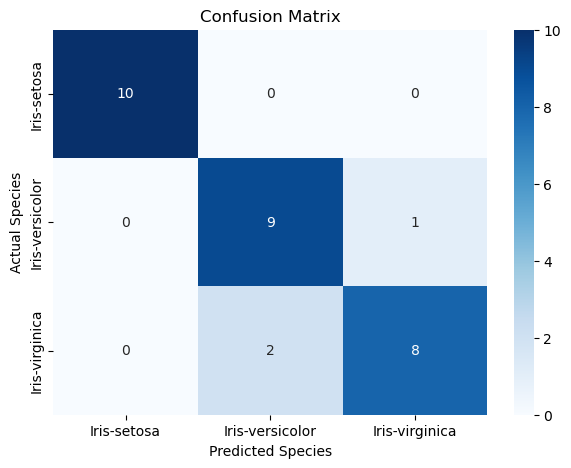

In [14]:
class_names = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=class_names)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

## 11. New Sample Prediction

In [16]:
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]],columns=X.columns)
prediction = model.predict(new_flower)

print("\nSample Flower Measurements:")
print(new_flower)

print("\nPredicted Iris Species:", prediction[0])


Sample Flower Measurements:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2

Predicted Iris Species: Iris-setosa


## 11. Conclusion

The Random Forest Classifier successfully classified Iris flowers into three species: Iris-setosa, Iris-versicolor, and Iris-virginica.

The model achieved an accuracy of approximately **90.00%** on the test dataset.

The project covered dataset exploration, target identification, data visualization, feature selection, train-test splitting, model training, prediction, and evaluation using a classification report and confusion matrix.

A sample flower was also passed to the trained model to demonstrate how the model can predict the species of a new Iris flower.

This project demonstrates a complete multi-class Machine Learning classification workflow using Python and Scikit-learn.